# Week 2 — RETROSPECTIVE Acquisition-Function "What-If" Analysis: Function_07

> **RETROSPECTIVE, COUNTERFACTUAL, AND UNEVALUATED.** This notebook computes what an acquisition function (Expected Improvement / Upper Confidence Bound / Probability of Improvement) would have recommended as the next query point, using **only** the data chronologically available at the start of Week_02 for this function. The recommended point(s) below were **never actually queried**, have **no associated real output**, were **never submitted anywhere**, and are **not** part of this project's genuine historical or live-submission data. This analysis is purely additive: it does not modify, and is not connected to, the existing verified `01_Notebook/week_02_eda_gp_surrogate.ipynb` or any other historical result.

**Track:** `Historical_Replay` (retrospective learning track). This is a new analysis layer, added after the fact, over a week that was already independently PASS-verified without any acquisition function (`Historical_Replay/Week_02/FINAL_EVALUATION.md`, Check 12: "No acquisition-driven query generated"). Nothing about that verified state is changed by this notebook.

**Function:** Function_07 | **Input dimensionality:** d = 6 | **Problem type:** maximisation (CLAUDE.md rule 17) | **Official bounds (every coordinate):** `[0.000000, 0.999999]` inclusive (CLAUDE.md rule 16).

**No lookahead.** This notebook uses only `../02_Data/cumulative_inputs.npy` / `cumulative_outputs.npy` (31 rows) — the exact same chronologically-valid Week_02 dataset already used by the existing, verified `../01_Notebook/week_02_eda_gp_surrogate.ipynb`. No Week_03, Week_04, or Week_05 file is read anywhere in this notebook, and no `03_Queries` folder is referenced or written.

## 1. Imports and configuration

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel, ConstantKernel

FUNCTION_NUMBER = 7
SEED = 42 + FUNCTION_NUMBER  # same seed convention used throughout this project
ACQ_SEED = 2000 + 42 + FUNCTION_NUMBER  # seed for multi-start acquisition optimisation
LOW, HIGH = 0.000000, 0.999999  # official bounds, inclusive (CLAUDE.md rule 16)
FIG_DIR = '.'  # figures saved alongside this notebook, in this new folder only

print('Function number:', FUNCTION_NUMBER)
print('GP seed (42 + function_number):', SEED)
print('Acquisition multi-start seed (2000 + 42 + function_number):', ACQ_SEED)


Function number: 7
GP seed (42 + function_number): 49
Acquisition multi-start seed (2000 + 42 + function_number): 2049


## 2. Load data (no lookahead)

Loads **only** this function's own Week_02 cumulative dataset, identical in content to the file already used by the existing, verified `01_Notebook/week_02_eda_gp_surrogate.ipynb`. This new notebook lives in `08_Retrospective_Acquisition/`, a sibling of `01_Notebook/` at the same folder depth under `Function_07/`, so the relative path `../02_Data/` resolves to the same data folder. No other file, function, or week is read.

In [2]:
inputs = np.load('../02_Data/cumulative_inputs.npy')
outputs = np.load('../02_Data/cumulative_outputs.npy')

n_obs, d_in = inputs.shape
EXPECTED_N = 31
EXPECTED_D = 6

print('inputs shape :', inputs.shape)
print('outputs shape:', outputs.shape)
assert n_obs == EXPECTED_N, 'Row count does not match Week_02 cumulative count for this function'
assert d_in == EXPECTED_D, 'Dimensionality does not match expected value for this function'
assert inputs.dtype == np.float64 and outputs.dtype == np.float64, 'Unexpected dtype'
assert not np.isnan(inputs).any() and not np.isnan(outputs).any(), 'NaN found'
assert not np.isinf(inputs).any() and not np.isinf(outputs).any(), 'Inf found'
assert np.all(inputs >= 0.0) and np.all(inputs <= 0.999999 + 1e-9), 'Inputs out of official bounds'
print('Sanity checks passed: shape, dimensionality, dtype, finiteness, bounds.')


inputs shape : (31, 6)
outputs shape: (31,)
Sanity checks passed: shape, dimensionality, dtype, finiteness, bounds.


## 3. Week_02's own kernel-selection outcome (Step 1 — read, not guessed)

Independently re-read from `../01_Notebook/week_02_eda_gp_surrogate.ipynb`'s Section 6a code-cell output for Function_07:

- RBF log-marginal-likelihood: `-33.09599836546624`
- Matern (nu=2.5) log-marginal-likelihood: `-33.41956276881404`
- Selection rule applied by Week_02's own notebook: **default (higher raw log-marginal-likelihood; both kernels converged cleanly)**
- **Kernel selected by Week_02's own process: RBF**

This function's own Week_02 notebook reported clean convergence for both kernels (no `ABNORMAL` L-BFGS-B terminations), so the default rule (higher raw log-marginal-likelihood) applies directly, with no convergence override needed.

Below, this notebook performs a **fresh, independent refit** of both kernels on the same data, using the same kernel construction, seed convention, and restart count, to confirm this selection reproduces deterministically before using it for the retrospective acquisition-function analysis.

## 4. Output standardization and fresh, independent GP refit

Output `y` is standardized (zero mean, unit variance) before fitting, exactly as in every other notebook in this project; every posterior mean/std is inverse-transformed back to the real output scale before any acquisition-function value is computed, since acquisition functions must operate in raw output units. Kernel construction: `ConstantKernel * (RBF|Matern(nu=2.5)) + WhiteKernel`, `n_restarts_optimizer=5`, `random_state=SEED`. This refit is independent of, and does not modify, the GP objects fitted in `../01_Notebook/week_02_eda_gp_surrogate.ipynb`.

In [3]:
y_mean = float(outputs.mean())
y_std = float(outputs.std(ddof=0))
if y_std == 0.0:
    y_std = 1.0
y_scaled = (outputs - y_mean) / y_std

def inverse_mean(m):
    return m * y_std + y_mean

def inverse_std(s):
    return s * y_std

def build_and_fit(kernel_type):
    d = inputs.shape[1]
    length_scale_init = np.ones(d)
    if kernel_type == 'rbf':
        base_kernel = RBF(length_scale=length_scale_init, length_scale_bounds=(1e-2, 1e2))
    elif kernel_type == 'matern':
        base_kernel = Matern(length_scale=length_scale_init, length_scale_bounds=(1e-2, 1e2), nu=2.5)
    else:
        raise ValueError(kernel_type)
    kernel = ConstantKernel(1.0, (1e-2, 1e2)) * base_kernel \
        + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-10, 1e1))
    gpr = GaussianProcessRegressor(
        kernel=kernel, alpha=1e-10, n_restarts_optimizer=5,
        normalize_y=False, random_state=SEED,
    )
    gpr.fit(inputs, y_scaled)
    return gpr

gpr_rbf = build_and_fit('rbf')
gpr_matern = build_and_fit('matern')

lml_rbf_refit = float(gpr_rbf.log_marginal_likelihood_value_)
lml_matern_refit = float(gpr_matern.log_marginal_likelihood_value_)
print('Refit RBF log-marginal-likelihood   :', lml_rbf_refit)
print('Refit Matern log-marginal-likelihood:', lml_matern_refit)
print('Matches Week_02 notebook (RBF)   :', np.isclose(lml_rbf_refit, -33.09599836546624))
print('Matches Week_02 notebook (Matern):', np.isclose(lml_matern_refit, -33.41956276881404))


Refit RBF log-marginal-likelihood   : -33.09599836546624
Refit Matern log-marginal-likelihood: -33.41956276881404
Matches Week_02 notebook (RBF)   : True
Matches Week_02 notebook (Matern): True


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may fin

In [4]:
SELECTED_KERNEL = 'rbf'  # Step 1 finding: RBF selected by Week_02's own process
selected_gpr = gpr_rbf if SELECTED_KERNEL == 'rbf' else gpr_matern
print('Kernel used for retrospective acquisition-function analysis:', 'RBF')


Kernel used for retrospective acquisition-function analysis: RBF


## 5. Best observed output so far (`f_best`)

Since this is a **maximisation** problem, `f_best` is the maximum recorded output in this function's own Week_02 cumulative dataset — the same quantity Week_02's own notebook reports in its Section 4 summary statistics, recomputed here independently.

In [5]:
f_best = float(outputs.max())
f_best_idx = int(np.argmax(outputs))
f_best_x = inputs[f_best_idx].copy()
print('f_best (best observed output, Week_02 cumulative data only):', f_best)
print('Achieved at input row', f_best_idx, ':', f_best_x)


f_best (best observed output, Week_02 cumulative data only): 1.3649683044991994
Achieved at input row 6 : [0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984]


## 6. Acquisition function definitions

All three acquisition functions are evaluated on the **real, raw output scale** (after inverse-transforming the standardized posterior mean/std), and are all oriented for **maximisation** (CLAUDE.md rule 17).

- **Expected Improvement (EI)**, `xi = 0.01` (raw output units):
  `improvement(x) = mu(x) - f_best - xi`
  `z(x) = improvement(x) / sigma(x)` if `sigma(x) > 0`, else `z(x) = 0`
  `EI(x) = improvement(x) * Phi(z(x)) + sigma(x) * phi(z(x))` if `sigma(x) > 0`, else `EI(x) = 0`
- **Upper Confidence Bound (UCB)**, `kappa = 2.0`:
  `UCB(x) = mu(x) + kappa * sigma(x)`
- **Probability of Improvement (PI)**, same `z(x)`/`xi` as EI:
  `PI(x) = Phi(z(x))`

Here `mu(x)`/`sigma(x)` are the GP posterior mean/std (already inverse-transformed to raw units), and `Phi`/`phi` are the standard normal CDF/PDF. `xi=0.01` and `kappa=2.0` are standard, moderate exploration-vs-exploitation settings, documented here explicitly per CLAUDE.md rule 5 (acquisition-function parameters must be documented).

In [6]:
XI = 0.01
KAPPA = 2.0

def posterior(X):
    """X: (m, d) array in raw input units -> (mu, sigma) in raw output units."""
    mu_s, sigma_s = selected_gpr.predict(X, return_std=True)
    mu = inverse_mean(mu_s)
    sigma = np.maximum(inverse_std(sigma_s), 0.0)
    return mu, sigma

def acquisitions(X):
    mu, sigma = posterior(X)
    improvement = mu - f_best - XI
    z = np.zeros_like(improvement)
    pos = sigma > 0
    z[pos] = improvement[pos] / sigma[pos]
    ei = np.zeros_like(improvement)
    ei[pos] = improvement[pos] * norm.cdf(z[pos]) + sigma[pos] * norm.pdf(z[pos])
    ucb = mu + KAPPA * sigma
    pi = norm.cdf(z)
    return {'EI': ei, 'UCB': ucb, 'PI': pi, 'mu': mu, 'sigma': sigma}


## 7. Maximise each acquisition function — multi-start L-BFGS-B (d = 6)

For d >= 3, a full grid is infeasible, so each acquisition function is maximised via multi-start `scipy.optimize.minimize` (method=`L-BFGS-B`, bounds enforced to `[0.000000, 0.999999]` in every dimension) on its negative, from 25 seeded random starting points (>= 20 required). Starting points are drawn once via `np.random.default_rng(2000 + 42 + function_number)` and reused identically across all three acquisition functions for a fair, directly-comparable multi-start search. The best (highest-acquisition-value) local optimum across all 25 starts is kept for each acquisition function.

In [7]:
N_STARTS = 25
rng = np.random.default_rng(ACQ_SEED)
starts = rng.uniform(LOW, HIGH, size=(N_STARTS, d_in))
bounds = [(LOW, HIGH)] * d_in

def neg_acq_factory(name):
    def _f(x):
        X = np.asarray(x, dtype=float).reshape(1, -1)
        return -float(acquisitions(X)[name][0])
    return _f

recommendations = {}
for name in ['EI', 'UCB', 'PI']:
    neg_f = neg_acq_factory(name)
    best_x, best_val, n_success = None, -np.inf, 0
    for x0 in starts:
        res = minimize(neg_f, x0, method='L-BFGS-B', bounds=bounds)
        if res.success:
            n_success += 1
        val = -res.fun
        if val > best_val:
            best_val = val
            best_x = np.clip(res.x, LOW, HIGH)
    recommendations[name] = {'x': best_x, 'value': float(best_val)}
    print(f'{name}: x* = {best_x}, value = {best_val:.6f} '
          f'({n_success}/{N_STARTS} starts converged successfully)')

print()
print('Starting points used per acquisition function:', N_STARTS)


EI: x* = [0.         0.07240483 0.75626949 0.22834104 0.37918204 0.75687807], value = 0.024556 (25/25 starts converged successfully)


UCB: x* = [0.         0.06442088 0.87433073 0.17509934 0.35998108 0.78107605], value = 1.552535 (25/25 starts converged successfully)


PI: x* = [0.         0.38503831 0.29571031 0.23543847 0.3937054  0.74785269], value = 0.400563 (25/25 starts converged successfully)

Starting points used per acquisition function: 25


## 8. Recommended points (retrospective, counterfactual, unevaluated)

Formatted per this project's official submission convention: six decimal places, hyphen-separated, leading zeros, no brackets/spaces/commas (CLAUDE.md rule 19). **These are hypothetical recommendations only — none of them were ever submitted or queried, and none has a real associated output.**

In [8]:
def fmt_point(x):
    return '-'.join(f'{v:.6f}' for v in x)

print(f'{"Acquisition":<6} {"Recommended point (retrospective, unqueried)":<40} {"Value":>12}')
for name in ['EI', 'UCB', 'PI']:
    r = recommendations[name]
    print(f'{name:<6} {fmt_point(r["x"]):<40} {r["value"]:>12.6f}')


Acquisition Recommended point (retrospective, unqueried)        Value
EI     0.000000-0.072405-0.756269-0.228341-0.379182-0.756878     0.024556
UCB    0.000000-0.064421-0.874331-0.175099-0.359981-0.781076     1.552535
PI     0.000000-0.385038-0.295710-0.235438-0.393705-0.747853     0.400563


## 9. Do EI, UCB, and PI agree or diverge?

Pairwise Euclidean distance between the three recommended points (in the normalised `[0, 1)^d` input space). As a simple, explicit rule of thumb *for this notebook only*, points within 0.1 Euclidean distance of each other are described as agreeing on a similar region; larger distances are described as diverging. This threshold is an interpretive convenience, not a formal statistical test.

In [9]:
pairs = [('EI', 'UCB'), ('EI', 'PI'), ('UCB', 'PI')]
AGREEMENT_THRESHOLD = 0.1
for a, b in pairs:
    dist = float(np.linalg.norm(recommendations[a]['x'] - recommendations[b]['x']))
    verdict = 'AGREE (similar region)' if dist < AGREEMENT_THRESHOLD else 'DIVERGE (different region)'
    print(f'{a} vs {b}: distance = {dist:.6f} -> {verdict}')


EI vs UCB: distance = 0.133383 -> DIVERGE (different region)
EI vs PI: distance = 0.556954 -> DIVERGE (different region)
UCB vs PI: distance = 0.665942 -> DIVERGE (different region)


## 10. Figure — acquisition value comparison (bar chart)

Since d = 6 >= 3, a full grid surface is infeasible to plot. Instead, a simple bar chart compares each acquisition function's value at its own retrospective recommended point. Saved to this new folder only (`acquisition_value_comparison.png`).

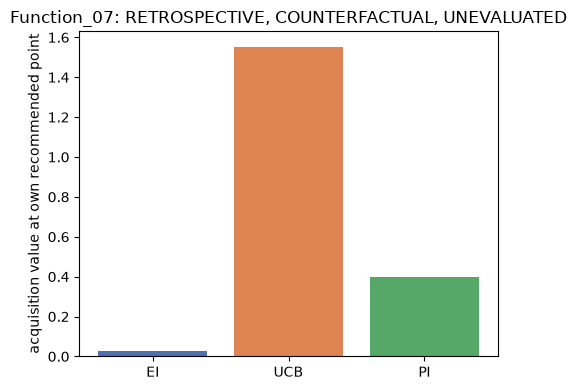

In [10]:
fig, ax = plt.subplots(figsize=(5, 4))
names = ['EI', 'UCB', 'PI']
vals = [recommendations[n]['value'] for n in names]
ax.bar(names, vals, color=['#4c72b0', '#dd8452', '#55a868'])
ax.set_ylabel('acquisition value at own recommended point')
ax.set_title(f'Function_{FUNCTION_NUMBER:02d}: RETROSPECTIVE, COUNTERFACTUAL, UNEVALUATED')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'acquisition_value_comparison.png'), dpi=150)
plt.show()


## 11. Scope, caveats, and repeated framing

> **RETROSPECTIVE, COUNTERFACTUAL, AND UNEVALUATED.** This notebook computes what an acquisition function (Expected Improvement / Upper Confidence Bound / Probability of Improvement) would have recommended as the next query point, using **only** the data chronologically available at the start of Week_02 for this function. The recommended point(s) below were **never actually queried**, have **no associated real output**, were **never submitted anywhere**, and are **not** part of this project's genuine historical or live-submission data. This analysis is purely additive: it does not modify, and is not connected to, the existing verified `01_Notebook/week_02_eda_gp_surrogate.ipynb` or any other historical result.

- **No lookahead.** Only this function's own `../02_Data/cumulative_inputs.npy`/`cumulative_outputs.npy` (31 rows) was used — the same chronologically-valid Week_02 snapshot as the existing verified notebook. No Week_03, Week_04, or Week_05 file was read.
- **No existing file was modified.** This notebook and its figure(s) are new files in a new folder (`Function_07/08_Retrospective_Acquisition/`), physically separate from `01_Notebook/`.
- **No `03_Queries` reference.** This notebook does not read from or write to any `03_Queries` folder, consistent with these recommended points never having been submitted.
- **Kernel provenance.** The kernel used above (RBF) is Week_02's own actual selection for Function_07, re-derived from a fresh, independent refit on the same data, seed, and kernel construction — not assumed.
